# Image Procesing

at [1] and [2], the addressed of the folder placed into your drive needs to be pasted.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CTD image folder: /content/drive/MyDrive/1A - Shared External/MOB 2026 Workshop
CTD image folder exists: True
Output folder: /content/drive/MyDrive/1A - Shared External/output/single_image_psd

Processing image: /content/drive/MyDrive/1A - Shared External/MOB 2026 Workshop/Agg_SlowCam_7200.bmp
Particles detected: 306
Contour steps saved to: /content/drive/MyDrive/1A - Shared External/output/single_image_psd/Agg_SlowCam_7200_contour_steps.png


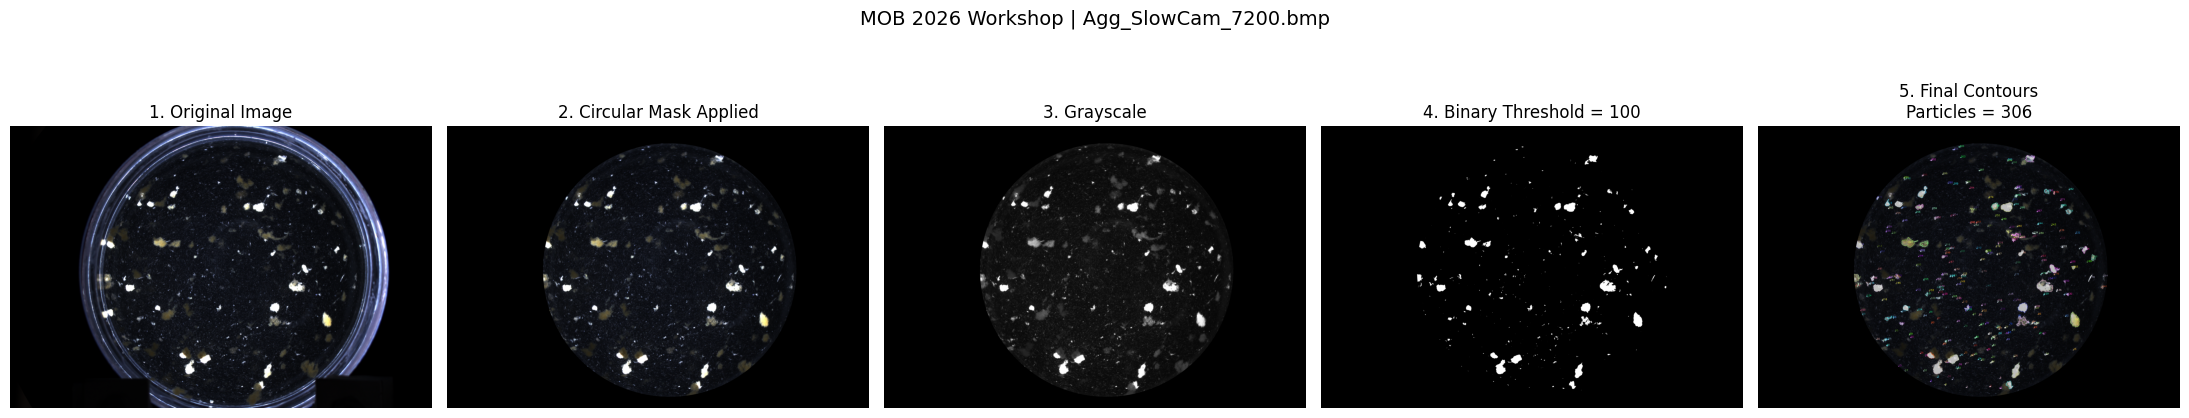

Particle data saved to: /content/drive/MyDrive/1A - Shared External/output/single_image_psd/Agg_SlowCam_7200_particle_data.csv
PSD binned data saved to: /content/drive/MyDrive/1A - Shared External/output/single_image_psd/Agg_SlowCam_7200_psd_volume_by_bin.csv
PSD graph saved to: /content/drive/MyDrive/1A - Shared External/output/single_image_psd/Agg_SlowCam_7200_particle_size_distribution.png


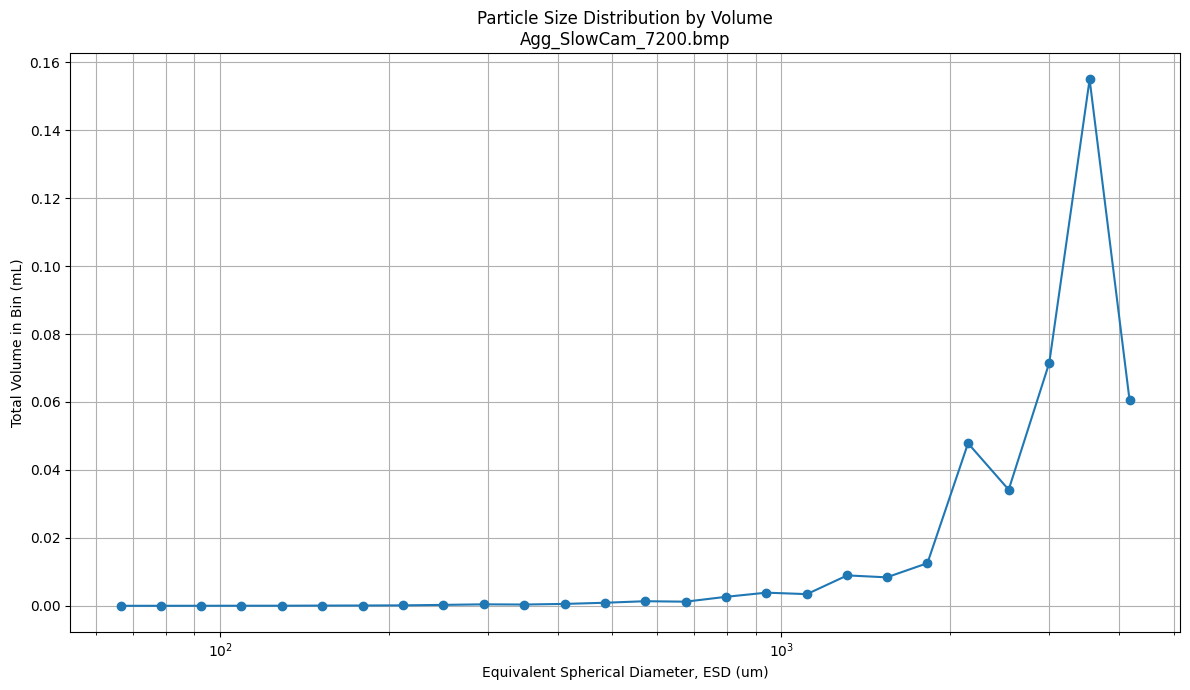


Finished one-image PSD analysis.
Outputs saved to: /content/drive/MyDrive/1A - Shared External/output/single_image_psd


In [ ]:

from google.colab import drive
drive.mount("/content/drive")

import os
import re
import sys
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import img_as_ubyte

# PASTE YOUR WORKING FOLDER ADDRESS HERE
# This folder should contain:
# rotating_calipers.py
# the BMP image/images you want to process
# output will be saved inside this same folder

WORKING_FOLDER_ADDRESS = r"/content/drive/MyDrive/1A - Shared External/MOB 2026 Workshop"

working_folder_path = Path(WORKING_FOLDER_ADDRESS)

# Use this same folder to import rotating_calipers.py
sys.path.insert(0, str(working_folder_path))
from rotating_calipers import min_max_feret

# Use this same folder as the image folder
ctd_image_folder_path = working_folder_path

# Output folder inside the same pasted folder
output_folder = working_folder_path / "output"
single_image_output_folder = output_folder / "single_image_psd"
single_image_output_folder.mkdir(parents=True, exist_ok=True)

print("Working folder:", working_folder_path)
print("Working folder exists:", working_folder_path.exists())
print("Output folder:", single_image_output_folder)


# Choose one image
# "filename" = choose exact BMP filename

IMAGE_SELECTION_MODE = "filename"

IMAGE_FILENAME = "Agg_SlowCam_7200.bmp"

# Display/save outputs
SHOW_CONTOUR_STEPS = True
SAVE_CONTOUR_STEPS = True

SHOW_PSD_GRAPH = True
SAVE_PSD_GRAPH = True

CONTOUR_SAVE_DPI = 150
PSD_SAVE_DPI = 300

print("CTD image folder:", ctd_image_folder_path)
print("CTD image folder exists:", ctd_image_folder_path.exists())
print("Output folder:", single_image_output_folder)



# 2. CALIBRATION, MASK, AND THRESHOLD SETTINGS
# Microns per pixel
calibration_data = {
    "Set1": 29.1
}

# Circular mask settings
mask_params = [
    {"center_x": 2900, "center_y": 1875, "radius": 1650}
]

# Binary threshold setting
threshold_data = {
    "Set1": 100
}

# Minimum contour area in pixels
min_particle_area = 5



# 3. IMAGE PROCESSING
def apply_fixed_mask(image_path, mask_center_x, mask_center_y, mask_radius):
    # Read in image
    original_image = cv2.imread(image_path)

    if original_image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Define tube mask function
    def tube_mask(image, center, radius):
        # Initialize mask
        mask = np.zeros_like(image)

        # Draw circle for mask
        cv2.circle(mask, center, radius, (255, 255, 255), -1)

        # Use mask to blackout particles outside of mask
        masked_image = cv2.bitwise_and(image, mask)

        return masked_image

    # Use specified sizes to make mask
    masked_image = tube_mask(
        original_image,
        (mask_center_x, mask_center_y),
        mask_radius
    )

    return masked_image


def process_image(image, um_per_px, threshold_value):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    binary = img_as_ubyte(binary)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_image = np.zeros_like(image)

    # List to store particle areas and centroids
    particle_data = []

    # Particle ID
    particle_id = 1

    # Draw contours without filling for particles
    for contour in contours:
        area = cv2.contourArea(contour)

        # Make sure area is greater than threshold area
        if area > min_particle_area:

            # Ellipse needs at least 5 contour points
            if len(contour) >= 5:

                # Convert pixel area to real-world area
                area_um = area * (um_per_px ** 2)

                # Centroid
                M = cv2.moments(contour)

                if M["m00"] == 0:
                    continue

                centroid_x = int(M["m10"] / M["m00"])
                centroid_y = int(M["m01"] / M["m00"])

                # Perimeter
                perimeter = cv2.arcLength(contour, True)
                perimeter_um = perimeter * um_per_px

                # Ellipse properties
                ellipse = cv2.fitEllipse(contour)
                major_axis_length = max(ellipse[1])
                major_axis_length_um = major_axis_length * um_per_px
                minor_axis_length = min(ellipse[1])
                minor_axis_length_um = minor_axis_length * um_per_px
                angle = ellipse[2]

                # Aspect ratio
                if minor_axis_length_um > 0:
                    aspect_ratio = major_axis_length_um / minor_axis_length_um
                else:
                    aspect_ratio = 0

                # Circularity
                if perimeter_um > 0:
                    circularity_um = (4 * np.pi * area_um) / (perimeter_um ** 2)
                else:
                    circularity_um = 0

                # Calculate Feret diameters and angles
                boundary_points = [tuple(point[0]) for point in contour]
                feret_result = min_max_feret(boundary_points)

                # Works if min_max_feret returns 4 values
                if len(feret_result) == 4:
                    min_feret, min_feret_angle, max_feret, max_feret_angle = feret_result

                # Works if min_max_feret returns only 2 values
                elif len(feret_result) == 2:
                    min_feret, max_feret = feret_result
                    min_feret_angle = 0
                    max_feret_angle = 0

                else:
                    min_feret = 0
                    min_feret_angle = 0
                    max_feret = 0
                    max_feret_angle = 0

                min_feret_um = min_feret * um_per_px
                max_feret_um = max_feret * um_per_px

                # Append particle data to the list
                particle_data.append({
                    "Particle ID": particle_id,
                    "Area (microns^2)": area_um,
                    "Centroid_X (pixels)": centroid_x,
                    "Centroid_Y (pixels)": centroid_y,
                    "Perimeter (um)": perimeter_um,
                    "Major Axis Length (um)": major_axis_length_um,
                    "Minor Axis Length (um)": minor_axis_length_um,
                    "Angle of Rotation (degrees)": angle,
                    "Circularity": circularity_um,
                    "Aspect Ratio": aspect_ratio,
                    "MinFeret (um)": min_feret_um,
                    "Min Feret Angle (degrees)": min_feret_angle,
                    "MaxFeret (um)": max_feret_um,
                    "Max Feret Angle (degrees)": max_feret_angle,
                    "Calibration (um_per_px)": um_per_px,
                    "Threshold": threshold_value
                })

                # Random color for drawing contours
                random_color = (
                    random.randint(0, 255),
                    random.randint(0, 255),
                    random.randint(0, 255)
                )

                cv2.drawContours(
                    contour_image,
                    [contour],
                    -1,
                    random_color,
                    thickness=2
                )

                if Show_ID:
                    cv2.putText(
                        contour_image,
                        str(particle_id),
                        (centroid_x, centroid_y),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        1,
                        random_color,
                        2
                    )

                particle_id += 1

    return contour_image, particle_data

def extract_image_number(image_filename):
    numbers = re.findall(r"\d+", image_filename)

    if len(numbers) == 0:
        return None

    return int(numbers[-1])


def get_sorted_bmp_files(folder_path):
    bmp_files = []

    for filename in os.listdir(folder_path):
        file_path = folder_path / filename

        if not file_path.is_file():
            continue

        if file_path.suffix.lower() != ".bmp":
            continue

        image_number = extract_image_number(filename)

        if image_number is None:
            continue

        bmp_files.append((image_number, filename, file_path))

    bmp_files = sorted(bmp_files, key=lambda x: x[0])

    return bmp_files


def choose_one_image():
    if not ctd_image_folder_path.exists():
        raise FileNotFoundError(f"CTD image folder does not exist: {ctd_image_folder_path}")

    if not ctd_image_folder_path.is_dir():
        raise NotADirectoryError(f"This is not a folder: {ctd_image_folder_path}")

    bmp_files = get_sorted_bmp_files(ctd_image_folder_path)

    if len(bmp_files) == 0:
        raise FileNotFoundError(f"No BMP files found in: {ctd_image_folder_path}")

    if IMAGE_SELECTION_MODE == "filename":
        image_path = ctd_image_folder_path / IMAGE_FILENAME

        if not image_path.exists():
            raise FileNotFoundError(f"Image file does not exist: {image_path}")

        return image_path

    elif IMAGE_SELECTION_MODE == "index":
        if IMAGE_INDEX < 0 or IMAGE_INDEX >= len(bmp_files):
            raise IndexError(
                f"IMAGE_INDEX={IMAGE_INDEX} is out of range. "
                f"Folder has {len(bmp_files)} BMP images."
            )

        return bmp_files[IMAGE_INDEX][2]

    elif IMAGE_SELECTION_MODE == "time":
        selected_index = int(TIME_HR / 0.5)

        if selected_index < 0 or selected_index >= len(bmp_files):
            raise IndexError(
                f"TIME_HR={TIME_HR} is out of range. "
                f"Folder has {len(bmp_files)} BMP images."
            )

        return bmp_files[selected_index][2]

    else:
        raise ValueError("IMAGE_SELECTION_MODE must be 'filename', 'index', or 'time'")



# 5. PARTICLE CALCULATION
def calculate_esd(area_microns_squared):
    return np.sqrt((4 / np.pi) * area_microns_squared)


def calculate_volume_mL(esd_um):
    volume_um3 = (4 / 3) * np.pi * (esd_um / 2) ** 3
    volume_mL = volume_um3 / 1e12

    return volume_mL


def calculate_spherical_area_um2(esd_um):
    return 4 * np.pi * (esd_um / 2) ** 2



# 6. SHOW CONTOURING STEPS
def process_one_image_for_psd():
    image_path = choose_one_image()

    print()
    print(f"Processing image: {image_path}")

    # Original Set1 settings
    set_name = "Set1"
    um_per_px = calibration_data[set_name]
    threshold_value = threshold_data[set_name]

    mask_center_x = mask_params[0]["center_x"]
    mask_center_y = mask_params[0]["center_y"]
    mask_radius = mask_params[0]["radius"]

    original_image = cv2.imread(str(image_path))

    if original_image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Original masking function
    masked_image = apply_fixed_mask(
        str(image_path),
        mask_center_x,
        mask_center_y,
        mask_radius
    )

    # Grayscale and binary only for visualization
    gray = cv2.cvtColor(masked_image, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    binary = img_as_ubyte(binary)

    # Original contouring function
    processed_image, particle_data_single = process_image(
        masked_image,
        um_per_px,
        threshold_value
    )

    print(f"Particles detected: {len(particle_data_single)}")

    # Convert BGR to RGB for plotting
    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    masked_rgb = cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB)
    contour_rgb = cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)

    overlay_rgb = cv2.addWeighted(
        masked_rgb,
        0.75,
        contour_rgb,
        1.0,
        0
    )

    # Show contouring steps
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(original_rgb)
    axes[0].set_title("1. Original Image")

    axes[1].imshow(masked_rgb)
    axes[1].set_title("2. Circular Mask Applied")

    axes[2].imshow(gray, cmap="gray")
    axes[2].set_title("3. Grayscale")

    axes[3].imshow(binary, cmap="gray")
    axes[3].set_title(f"4. Binary Threshold = {threshold_value}")

    axes[4].imshow(overlay_rgb)
    axes[4].set_title(f"5. Final Contours\nParticles = {len(particle_data_single)}")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{ctd_image_folder_path.name} | {image_path.name}",
        fontsize=14
    )

    plt.tight_layout()

    if SAVE_CONTOUR_STEPS:
        contour_save_path = single_image_output_folder / f"{image_path.stem}_contour_steps.png"

        plt.savefig(
            contour_save_path,
            dpi=CONTOUR_SAVE_DPI,
            bbox_inches="tight"
        )

        print(f"Contour steps saved to: {contour_save_path}")

    if SHOW_CONTOUR_STEPS:
        plt.show()
    else:
        plt.close()

    return image_path, particle_data_single



# 7. PARTICLE SIZE DISTRIBUTION GRAPH
def make_particle_size_distribution(image_path, particle_data_single):
    if len(particle_data_single) == 0:
        print("No particles detected. Cannot make PSD graph.")
        return pd.DataFrame(), pd.DataFrame()

    psd_rows = []

    for particle in particle_data_single:
        area_microns_squared = particle["Area (microns^2)"]
        esd_um = calculate_esd(area_microns_squared)
        volume_mL = calculate_volume_mL(esd_um)
        spherical_area_um2 = calculate_spherical_area_um2(esd_um)

        row = particle.copy()
        row["ESD (um)"] = esd_um
        row["Volume (mL)"] = volume_mL
        row["Spherical Area (um^2)"] = spherical_area_um2

        psd_rows.append(row)

    psd_df = pd.DataFrame(psd_rows)

    # ESD bins from older PSD / volume-by-bin workflow
    bins = [
        0.00E+00, 1.25E+00, 1.48E+00, 1.74E+00, 2.05E+00, 2.42E+00,
        2.86E+00, 3.38E+00, 3.98E+00, 4.70E+00, 5.55E+00, 6.55E+00,
        7.72E+00, 9.12E+00, 1.08E+01, 1.27E+01, 1.50E+01, 1.77E+01,
        2.09E+01, 2.46E+01, 2.91E+01, 3.43E+01, 4.05E+01, 4.77E+01,
        5.63E+01, 6.65E+01, 7.84E+01, 9.26E+01, 1.09E+02, 1.29E+02,
        1.52E+02, 1.80E+02, 2.12E+02, 2.50E+02, 2.95E+02, 3.48E+02,
        4.11E+02, 4.85E+02, 5.72E+02, 6.75E+02, 7.97E+02, 9.40E+02,
        1.11E+03, 1.31E+03, 1.54E+03, 1.82E+03, 2.15E+03, 2.54E+03,
        3.00E+03, 3.54E+03, 4.17E+03, 4.92E+03, 5.81E+03, 6.86E+03,
        8.09E+03, 9.55E+03, 1.13E+04
    ]

    psd_df["ESD_bin"] = pd.cut(
        psd_df["ESD (um)"],
        bins=bins,
        labels=bins[:-1],
        include_lowest=True
    )

    # Volume distribution by size bin
    volume_by_bin = (
        psd_df
        .groupby("ESD_bin", observed=False)["Volume (mL)"]
        .sum()
        .reset_index()
    )

    # Particle count by size bin
    count_by_bin = (
        psd_df
        .groupby("ESD_bin", observed=False)["Particle ID"]
        .count()
        .reset_index()
        .rename(columns={"Particle ID": "Particle Count"})
    )

    distribution_df = volume_by_bin.merge(
        count_by_bin,
        on="ESD_bin",
        how="left"
    )

    distribution_df["ESD_bin"] = distribution_df["ESD_bin"].astype(float)

    # Remove empty bins from graph
    distribution_nonzero = distribution_df[
        distribution_df["Volume (mL)"] > 0
    ].copy()

    # Save particle-level data
    particle_csv_path = single_image_output_folder / f"{image_path.stem}_particle_data.csv"
    psd_df.to_csv(particle_csv_path, index=False)

    # Save binned PSD data
    psd_csv_path = single_image_output_folder / f"{image_path.stem}_psd_volume_by_bin.csv"
    distribution_df.to_csv(psd_csv_path, index=False)

    print(f"Particle data saved to: {particle_csv_path}")
    print(f"PSD binned data saved to: {psd_csv_path}")

    # Plot PSD graph
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.plot(
        distribution_nonzero["ESD_bin"],
        distribution_nonzero["Volume (mL)"],
        marker="o",
        linewidth=1.5
    )

    ax.set_xscale("log")
    ax.set_xlabel("Equivalent Spherical Diameter, ESD (um)")
    ax.set_ylabel("Total Volume in Bin (mL)")
    ax.set_title(f"Particle Size Distribution by Volume\n{image_path.name}")

    ax.grid(True, which="both")

    plt.tight_layout()

    if SAVE_PSD_GRAPH:
        psd_plot_path = single_image_output_folder / f"{image_path.stem}_particle_size_distribution.png"

        plt.savefig(
            psd_plot_path,
            dpi=PSD_SAVE_DPI,
            bbox_inches="tight"
        )

        print(f"PSD graph saved to: {psd_plot_path}")

    if SHOW_PSD_GRAPH:
        plt.show()
    else:
        plt.close()

    return psd_df, distribution_df



# 8. RUN
image_path, particle_data_single = process_one_image_for_psd()

psd_df, distribution_df = make_particle_size_distribution(
    image_path,
    particle_data_single
)

print()
print("Finished one-image PSD analysis.")
print(f"Outputs saved to: {single_image_output_folder}")